In [1]:
import sys
import time
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.lines import Line2D
from tqdm.auto import tqdm
from genkit import AlphaStableFlowLinear, DLPMEps, DLPMEpsOrigin, GaussianFlowDDPM, GaussianFlowLinear, GaussianFlowOT, ScoreSDEOrigin
from genkit.diffusion import DDPMV, DDPMX0
from genkit.datasets import fetch_real_data, fetch_synthetic_data
from genkit.metrics import metric_on_quantile, mmd_rbf, mssle, wasserstein_distance
from genkit.nn import MLPModel
from genkit.plotting import PRETTY_RCPARAMS
from genkit.training import train
from genkit.visitor import CoreMetricsVisitor
from genkit.utils import format_duration

repo_root = Path.cwd().resolve()
if not (repo_root / "benchmarks" / "_utils.py").exists() and (repo_root.parent / "benchmarks" / "_utils.py").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from benchmarks._utils import summarize_metric_values, format_mean_std_latex

plt.rcParams.update(PRETTY_RCPARAMS)


/home/hcherkaoui/src/flowbench/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
depth = 3
width = 32
time_dim = 8

n_steps = 128
n_epochs = 1024
n_trials = 2
use_adamw = False
num_workers = 0

device = "cuda" if torch.cuda.is_available() else "cpu"
fdtype = torch.float32
idtype = torch.int32

model_specs = [
    # {
    #     "name": "DDPM-V",
    #     "cls": DDPMV,
    #     "source_distri": "Gaussian",
    #     "extra_kwargs": {},
    #     "train_kwargs": {"lr": 1e-3, "batch_size": 1024, "grad_clip_norm": 10.0},
    #     "color": "tab:green",
    #     "linestyle": "solid",
    #     "marker": "o",
    # },
    # {
    #     "name": "DDPM-X0",
    #     "cls": DDPMX0,
    #     "source_distri": "Gaussian",
    #     "extra_kwargs": {},
    #     "train_kwargs": {"lr": 1e-3, "batch_size": 1024, "grad_clip_norm": 10.0},
    #     "color": "tab:olive",
    #     "linestyle": "dashed",
    #     "marker": "s",
    # },
    {
        "name": "GF-Linear",
        "cls": GaussianFlowLinear,
        "source_distri": "Gaussian",
        "extra_kwargs": {},
        "train_kwargs": {"lr": 1e-3, "batch_size": 1024, "grad_clip_norm": 10.0},
        "color": "tab:blue",
        "linestyle": "solid",
        "marker": "^",
    },
    # {
    #     "name": "GF-OT",
    #     "cls": GaussianFlowOT,
    #     "source_distri": "Gaussian",
    #     "extra_kwargs": {},
    #     "train_kwargs": {"lr": 5e-4, "batch_size": 1024, "grad_clip_norm": 10.0},
    #     "color": "tab:purple",
    #     "linestyle": "dashdot",
    #     "marker": "P",
    # },
    # {
    #     "name": "GF-DDPM",
    #     "cls": GaussianFlowDDPM,
    #     "source_distri": "Gaussian",
    #     "extra_kwargs": {},
    #     "train_kwargs": {"lr": 5e-4, "batch_size": 1024, "grad_clip_norm": 10.0},
    #     "color": "tab:red",
    #     "linestyle": "dotted",
    #     "marker": "X",
    # },
    {
        "name": "ASF-Linear",
        "cls": AlphaStableFlowLinear,
        "source_distri": "AlphaStable",
        "extra_kwargs": {"alpha": 1.6},
        "train_kwargs": {"lr": 5e-3, "batch_size": 1024, "grad_clip_norm": 10.0},
        "color": "tab:brown",
        "linestyle": "dashdot",
        "marker": "v",
    },
    # {
    #     "name": "DLPM",
    #     "cls": DLPMEps,
    #     "source_distri": "AlphaStable",
    #     "extra_kwargs": {"alpha": 1.6},
    #     "train_kwargs": {"lr": 5e-4, "batch_size": 1024, "grad_clip_norm": 10.0},
    #     "color": "tab:orange",
    #     "linestyle": "dotted",
    #     "marker": "D",
    # },
    # {
    #     "name": "DLPM-Orig",
    #     "cls": DLPMEpsOrigin,
    #     "source_distri": "AlphaStable",
    #     "extra_kwargs": {"alpha": 1.6},
    #     "train_kwargs": {"lr": 5e-4, "batch_size": 1024, "grad_clip_norm": 10.0},
    #     "color": "tab:pink",
    #     "linestyle": "solid",
    #     "marker": "h",
    # },
    # {
    #     "name": "ScoreSDE-Orig",
    #     "cls": ScoreSDEOrigin,
    #     "source_distri": "Gaussian",
    #     "extra_kwargs": {},
    #     "train_kwargs": {"lr": 5e-3, "batch_size": 1024, "grad_clip_norm": 10.0},
    #     "color": "tab:cyan",
    #     "linestyle": "dashed",
    #     "marker": "*",
    # },
]

# Oracle baseline: x_val is an independent sample from the target law, so this is the split-noise floor, not a literal zero-error reference.
oracle_spec = {
    "name": "Oracle (x_val)",
    "color": "black",
    "linestyle": "dashed",
    "marker": "x",
}

tail_plot_specs = model_specs + [oracle_spec]
source_order = [oracle_spec["name"]] + [spec["name"] for spec in model_specs]
source_colors = {spec["name"]: spec["color"] for spec in tail_plot_specs}
net_kwargs = {"width": width, "depth": depth, "time_dim": time_dim}
base_train_kwargs = {
    "n_epochs": n_epochs,
    "use_adamw": use_adamw,
    "num_workers": num_workers,
    "device": device,
}


In [3]:
runs = []
trial_refs = {}
trial_oracles = {}

total_runs = len(model_specs) * n_trials
run_idx = 0

for trial_idx in range(n_trials):

    # x_train, x_val, x_ref = fetch_real_data("earthquakes", standardize=True, random_state=trial_idx, device=device, dtype=fdtype)
    x_train, x_val, x_ref = fetch_synthetic_data("alpha_stable", alpha=1.6, n_samples=50_000, val_size=0.3, test_size=0.3, dim=3, device=device, dtype=fdtype)

    n_samples, dim = x_train.shape

    trial_refs[trial_idx] = x_ref[: min(n_samples, x_ref.shape[0])].clone()
    trial_oracles[trial_idx] = x_val[: min(n_samples, x_val.shape[0])].clone()

    for spec in model_specs:
        run_idx += 1
        core_visitor = CoreMetricsVisitor()
        net = MLPModel(dim=dim, **net_kwargs).to(device=device, dtype=fdtype)
        generator = spec["cls"](
            net=net,
            dim=dim,
            n_steps=n_steps,
            device=device,
            fdtype=fdtype,
            idtype=idtype,
            **spec["extra_kwargs"],
        )
        run_train_kwargs = {**base_train_kwargs, **spec.get("train_kwargs", {})}

        t0 = time.perf_counter()
        msg = (
            f"[{run_idx:02d}/{total_runs:02d}] trial {trial_idx + 1}/{n_trials} {spec['name']}: "
            f"Training (nb samples: {n_samples}, dim: {dim}, max: {x_train.max():.1f}, "
            f"min: {x_train.min():.1f}, lr: {run_train_kwargs['lr']:.1e}, "
            f"batch: {run_train_kwargs['batch_size']}, clip: {run_train_kwargs['grad_clip_norm']})..."
        )
        print(msg, end="")
        generator, diagnostics = train(
            generative_model=generator,
            target_data=x_train.clone(),
            visitors=[core_visitor],
            **run_train_kwargs,
        )
        print(f"Done (in {format_duration(time.perf_counter() - t0)} s).")

        runs.append(
            {
                "trial_idx": trial_idx,
                "model": spec["name"],
                "source_distri": spec["source_distri"],
                "extra_kwargs": dict(spec["extra_kwargs"]),
                "train_kwargs": dict(run_train_kwargs),
                "generator": generator,
                "training_loss": diagnostics.get("visitors", {}).get("core", {}).get("training_loss", []),
                "grad_variance_epoch": diagnostics.get("visitors", {}).get("core", {}).get("grad_variance_epoch", []),
                "grad_norm_epoch": diagnostics.get("visitors", {}).get("core", {}).get("grad_norm_epoch", []),
            }
        )


[01/04] trial 1/2 GF-Linear: Training (nb samples: 19999, dim: 3, max: 154.3, min: -124.8, lr: 1.0e-03, batch: 1024, clip: 10.0)...Done (in 2min 59s s).
[02/04] trial 1/2 ASF-Linear: Training (nb samples: 19999, dim: 3, max: 154.3, min: -124.8, lr: 5.0e-03, batch: 1024, clip: 10.0)...Done (in 3min 9s s).
[03/04] trial 2/2 GF-Linear: Training (nb samples: 19999, dim: 3, max: 600.0, min: -1220.5, lr: 1.0e-03, batch: 1024, clip: 10.0)...Done (in 2min 56s s).
[04/04] trial 2/2 ASF-Linear: Training (nb samples: 19999, dim: 3, max: 600.0, min: -1220.5, lr: 5.0e-03, batch: 1024, clip: 10.0)...Done (in 3min 6s s).


In [4]:
n_samples = 15_000
eval_rows = []
tail_curves = []
n_pts = 7
xis = np.r_[0.0, 0.1, 0.5, 1 - np.logspace(-1, -2, n_pts - 3)]
xis = np.unique(np.round(xis, 6))

for run in tqdm(runs, desc="Evaluating runs"):
    x_ref = trial_refs[run["trial_idx"]].clone()[:n_samples, :]
    x_gen = run["generator"].sample(n_samples=n_samples)

    metrics = {
        "WASS": float(wasserstein_distance(x_ref.clone(), x_gen)),
        "MMD_RBF": float(mmd_rbf(x_ref.clone(), x_gen)),
        "MSSLE_95": float(metric_on_quantile(mssle, x_ref.clone(), x_gen, xi=0.95)),
        "MSSLE_99": float(metric_on_quantile(mssle, x_ref.clone(), x_gen, xi=0.99)),
    }
    eval_rows.append(
        {
            "model": run["model"],
            "trial_idx": run["trial_idx"],
            "source_distri": run["source_distri"],
            **metrics,
        }
    )
    tail_curves.append(
        {
            "model": run["model"],
            "trial_idx": run["trial_idx"],
            "xi": xis,
            "mssle": np.array([
                metric_on_quantile(mssle, x_ref.clone(), x_gen, xi=float(xi), reduction="mean")
                for xi in xis
            ]),
            "wasserstein": np.array([
                metric_on_quantile(wasserstein_distance, x_ref.clone(), x_gen, xi=float(xi))
                for xi in xis
            ]),
        }
    )

for trial_idx, x_ref_full in trial_refs.items():
    x_ref = x_ref_full.clone()[:n_samples, :]
    x_gen = trial_oracles[trial_idx].clone()[:n_samples, :]
    metrics = {
        "WASS": float(wasserstein_distance(x_ref.clone(), x_gen)),
        "MMD_RBF": float(mmd_rbf(x_ref.clone(), x_gen)),
        "MSSLE_95": float(metric_on_quantile(mssle, x_ref.clone(), x_gen, xi=0.95)),
        "MSSLE_99": float(metric_on_quantile(mssle, x_ref.clone(), x_gen, xi=0.99)),
    }
    eval_rows.append(
        {
            "model": oracle_spec["name"],
            "trial_idx": trial_idx,
            "source_distri": "Oracle",
            **metrics,
        }
    )
    tail_curves.append(
        {
            "model": oracle_spec["name"],
            "trial_idx": trial_idx,
            "xi": xis,
            "mssle": np.array([
                metric_on_quantile(mssle, x_ref.clone(), x_gen, xi=float(xi), reduction="mean")
                for xi in xis
            ]),
            "wasserstein": np.array([
                metric_on_quantile(wasserstein_distance, x_ref.clone(), x_gen, xi=float(xi))
                for xi in xis
            ]),
        }
    )

eval_df = pd.DataFrame(eval_rows)


Evaluating runs: 100%|██████████| 4/4 [03:40<00:00, 55.14s/it]


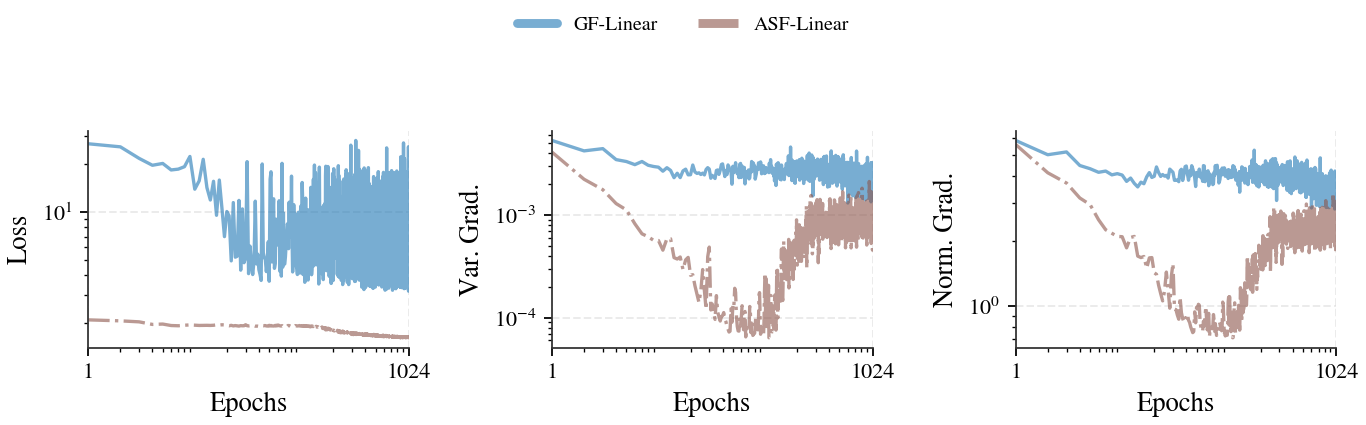

In [5]:
curve_runs = {
    spec["name"]: [run for run in runs if run["model"] == spec["name"]]
    for spec in model_specs
}

def average_run_curve(model_runs, key):
    curves = [np.asarray(run[key], dtype=float) for run in model_runs if run[key]]
    min_len = min(len(curve) for curve in curves)
    return np.mean(np.stack([curve[:min_len] for curve in curves], axis=0), axis=0)

avg_loss_by_model = {spec["name"]: average_run_curve(curve_runs[spec["name"]], "training_loss") for spec in model_specs}
avg_grad_var_by_model = {spec["name"]: average_run_curve(curve_runs[spec["name"]], "grad_variance_epoch") for spec in model_specs}
avg_grad_norm_by_model = {spec["name"]: average_run_curve(curve_runs[spec["name"]], "grad_norm_epoch") for spec in model_specs}
max_loss_epochs = max(curve.size for curve in avg_loss_by_model.values())
max_grad_var_epochs = max(curve.size for curve in avg_grad_var_by_model.values())
max_grad_norm_epochs = max(curve.size for curve in avg_grad_norm_by_model.values())

fig, axis = plt.subplots(1, 3, figsize=(8.8, 2.5), squeeze=False)

for spec in model_specs:
    color = source_colors[spec["name"]]
    avg_loss = avg_loss_by_model[spec["name"]]
    avg_grad_var = avg_grad_var_by_model[spec["name"]]
    avg_grad_norm = avg_grad_norm_by_model[spec["name"]]
    axis[0, 0].plot(np.arange(1, avg_loss.size + 1), avg_loss, color=color, linestyle=spec["linestyle"], lw=1.5, alpha=0.6)
    axis[0, 1].plot(np.arange(1, avg_grad_var.size + 1), avg_grad_var, color=color, linestyle=spec["linestyle"], lw=1.5, alpha=0.6)
    axis[0, 2].plot(np.arange(1, avg_grad_norm.size + 1), avg_grad_norm, color=color, linestyle=spec["linestyle"], lw=1.5, alpha=0.6)

axis[0, 0].set_xscale("log")
axis[0, 0].set_yscale("log")
axis[0, 0].set_xlim(1, max_loss_epochs)
axis[0, 0].set_xticks([1, max_loss_epochs], ["1", f"{max_loss_epochs}"])
axis[0, 0].set_xlabel("Epochs")
axis[0, 0].set_ylabel("Loss")

axis[0, 1].set_xscale("log")
axis[0, 1].set_yscale("log")
axis[0, 1].set_xlim(1, max_grad_var_epochs)
axis[0, 1].set_xticks([1, max_grad_var_epochs], ["1", f"{max_grad_var_epochs}"])
axis[0, 1].set_xlabel("Epochs")
axis[0, 1].set_ylabel("Var. Grad.")

axis[0, 2].set_xscale("log")
axis[0, 2].set_yscale("log")
axis[0, 2].set_xlim(1, max_grad_norm_epochs)
axis[0, 2].set_xticks([1, max_grad_norm_epochs], ["1", f"{max_grad_norm_epochs}"])
axis[0, 2].set_xlabel("Epochs")
axis[0, 2].set_ylabel("Norm. Grad.")

legend_handles = [Line2D([0], [0], color=source_colors[spec["name"]], lw=4.0, linestyle=spec["linestyle"], label=spec["name"], alpha=0.6)
                  for spec in model_specs]
fig.legend(legend_handles, [handle.get_label() for handle in legend_handles],
           loc="upper center", bbox_to_anchor=(0.5, 1.12), ncol=min(4, len(model_specs)), frameon=False, fontsize=9)
fig.tight_layout(rect=(0, 0, 1.0, 0.86))


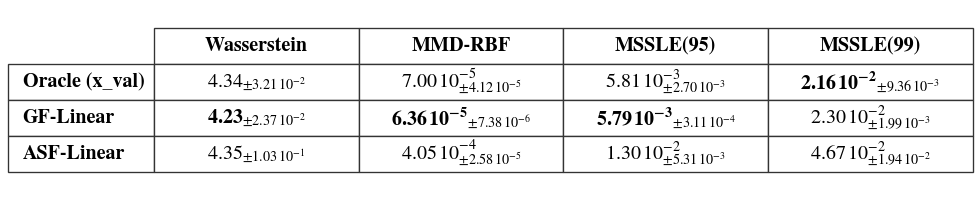

In [6]:
summary_rows = []
for model_name in source_order:
    model_df = eval_df[eval_df["model"] == model_name]
    row = {"model": model_name, "n_trials": len(model_df)}
    for metric_name in ("WASS", "MMD_RBF", "MSSLE_95", "MSSLE_99"):
        metric_summary = summarize_metric_values(model_df[metric_name].tolist())
        row[metric_name] = metric_summary["mean"]
        row[f"{metric_name}_std"] = metric_summary["std"]
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("model").loc[source_order]
best_by_metric = {
    metric_name: summary_df[metric_name].idxmin()
    for metric_name in ["WASS", "MMD_RBF", "MSSLE_95", "MSSLE_99"]
}
formatted = summary_df[["WASS", "MMD_RBF", "MSSLE_95", "MSSLE_99"]].copy().astype(object)
for row_label in formatted.index:
    formatted.loc[row_label, "WASS"] = format_mean_std_latex(summary_df.loc[row_label, "WASS"], summary_df.loc[row_label, "WASS_std"], bold=row_label == best_by_metric["WASS"])
    formatted.loc[row_label, "MMD_RBF"] = format_mean_std_latex(summary_df.loc[row_label, "MMD_RBF"], summary_df.loc[row_label, "MMD_RBF_std"], bold=row_label == best_by_metric["MMD_RBF"])
    formatted.loc[row_label, "MSSLE_95"] = format_mean_std_latex(summary_df.loc[row_label, "MSSLE_95"], summary_df.loc[row_label, "MSSLE_95_std"], bold=row_label == best_by_metric["MSSLE_95"])
    formatted.loc[row_label, "MSSLE_99"] = format_mean_std_latex(summary_df.loc[row_label, "MSSLE_99"], summary_df.loc[row_label, "MSSLE_99_std"], bold=row_label == best_by_metric["MSSLE_99"])

fig, axis = plt.subplots(1, 1, figsize=(6.6, 1.5), squeeze=False)
axis[0, 0].axis("off")
table = axis[0, 0].table(
    cellText=formatted.values,
    rowLabels=formatted.index,
    colLabels=["Wasserstein", "MMD-RBF", "MSSLE(95)", "MSSLE(99)"],
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 1.35)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("0.2")
    cell.set_linewidth(0.6)
    if row == 0 or col == -1:
        cell.set_text_props(weight="bold")

plt.show()


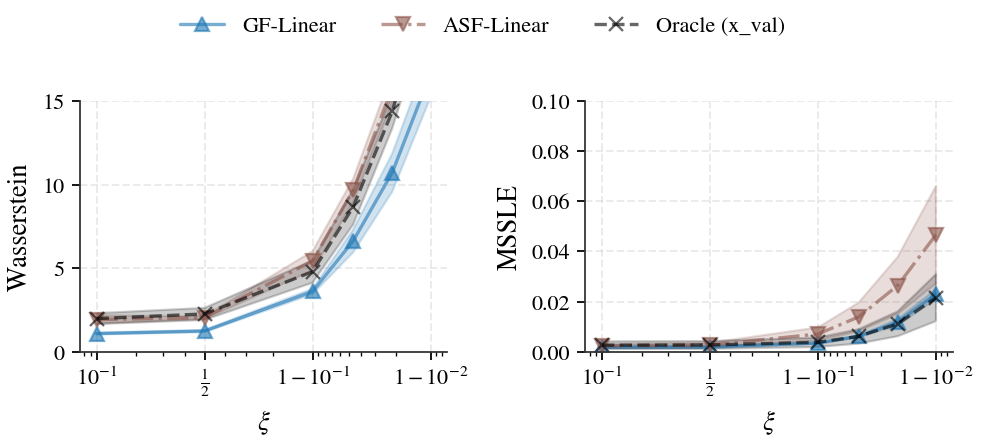

In [7]:
metric_specs = [
    ("wasserstein", "Wasserstein"),
    ("mssle", "MSSLE"),
]
ylims = [15.0, 0.1]
fig, axes = plt.subplots(1, 2, figsize=(6.5, 2.5), sharex=True)

for ax, (metric_key, metric_label), ylim in zip(axes, metric_specs, ylims):
    for spec in tail_plot_specs:
        model_curves = [curve for curve in tail_curves if curve["model"] == spec["name"]]
        if not model_curves:
            continue
        avg_curve = np.mean(np.stack([curve[metric_key] for curve in model_curves], axis=0), axis=0)
        std_curve = np.std(np.stack([curve[metric_key] for curve in model_curves], axis=0), axis=0)
        ax.plot(xis, avg_curve, lw=1.5, color=source_colors[spec["name"]], linestyle=spec["linestyle"], marker=spec["marker"], label=spec["name"], alpha=0.6)
        ax.fill_between(xis, avg_curve - std_curve, avg_curve + std_curve, color=source_colors[spec["name"]], alpha=0.2)

    ax.set_ylim(bottom=0, top=ylim)
    ax.set_xscale("logit")
    ax.set_xlabel(r"$\xi$")
    ax.set_ylabel(metric_label)

legend_handles = []
legend_labels = []
for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    for handle, label in zip(handles, labels):
        if label not in legend_labels:
            legend_handles.append(handle)
            legend_labels.append(label)

fig.legend(legend_handles, legend_labels, loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=min(4, len(legend_labels)), frameon=False, fontsize=10)

fig.tight_layout()
plt.show()
